# Analiza pokrycia teranu we Wrocławiu

In [5]:
!pip install rasterio owslib pillow matplotlib numpy requests


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\kubas\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import os
import random
import shutil
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image

## Pobieranie fragmentów mapy Wrocławia z API
https://gis1.um.wroc.pl/arcgis/rest/services/ogc/OGC_ortofoto_2024/MapServer

In [ ]:
URL = "http://gis1.um.wroc.pl/arcgis/rest/services/ogc/OGC_ortofoto_2024/MapServer/export"

OUT_DIR = "tiles_wroclaw"
os.makedirs(OUT_DIR, exist_ok=True)

origin_x = 877300
origin_y = 10001299.9999996

resolution = 0.5291677250021167
STEP = 512 * resolution 

XMIN, YMIN = 6416000, 5656500
XMAX, YMAX = 6443200, 5676000

In [ ]:
def snap(value: int, origin: float, step: float) -> float:
    return origin + round((value - origin) / step) * step

x_start = snap(XMIN, origin_x, STEP)
y_start = snap(YMAX, origin_y, STEP)

## Funkjca do pobierania konkretnych wycinków mapy

In [ ]:
def download(xmin: float, ymin: float, xmax: float, ymax: float, i: int, j: int) -> None:
    params = {
        "bbox": f"{xmin},{ymin},{xmax},{ymax}",
        "bboxSR": 2177,
        "imageSR": 2177,
        "size": "512,512",
        "format": "jpg",
        "f": "image"
    }

    r = requests.get(URL, params=params, timeout=30)

    if r.status_code != 200:
        print("skip", i, j)
        return

    try:
        img = Image.open(BytesIO(r.content))
        path = os.path.join(OUT_DIR, f"tile_{i}_{j}.jpg")
        img.save(path)
        print("ok", i, j)

    except Exception:
        print("bad image", i, j)

In [ ]:
i = 0
y = y_start

while y > YMIN:
    j = 0
    x = x_start

    while x < XMAX:

        download(x, y - STEP, x + STEP, y, i, j)

        x += STEP
        j += 1

    y -= STEP
    i += 1

print("DONE")

## Filtrowanie płytek 
Niektóre z płytek zawirają tylko obszary znajdujące się poza mapą (brak zdjęcia satelitarnego). Nie bierzemy pod uwagę płytek, które zawirają więcej niż 10% takich obszarów

In [23]:
INPUT_DIR = "tiles_wroclaw"
OUTPUT_DIR = "tiles_wroclaw_filtered"

threshold = 0.10

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [24]:
def white_ratio(img: Image.Image) -> float:

    arr = np.array(img)

    white_mask = np.all(arr == 253, axis=-1)

    num_white = np.sum(white_mask)
    total = white_mask.size

    return num_white / total

In [25]:
files = [
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Found {len(files)} images")

Found 7373 images


In [ ]:
kept = 0
removed = 0

for filename in files:

    path = os.path.join(INPUT_DIR, filename)

    try:
        img = Image.open(path).convert("RGB")

        ratio = white_ratio(img)

        if ratio <= threshold:
            out_path = os.path.join(OUTPUT_DIR, filename)
            shutil.copy2(path, out_path)
            kept += 1
        else:
            removed += 1

    except Exception as e:
        print("ERROR:", filename, e)

print()
print("DONE")
print("Kept:", kept)
print("Removed:", removed)


DONE
Kept: 5697
Removed: 1676


## Przykładowe kawałki mapy Wrocławia

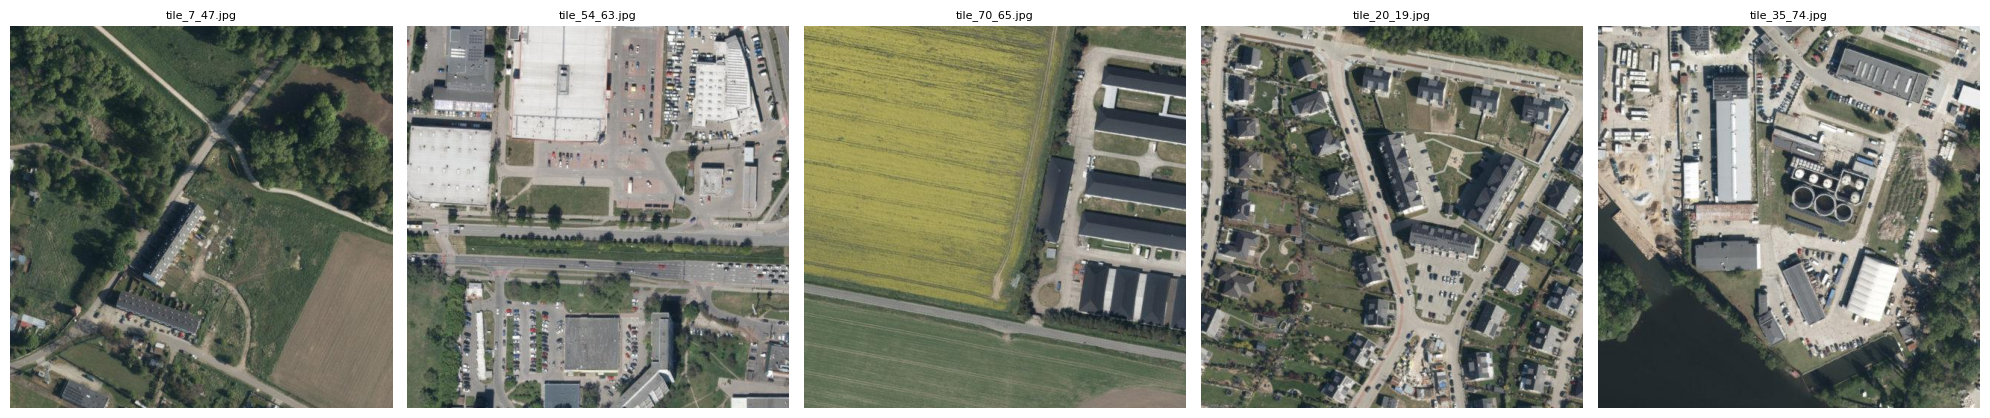

In [48]:
DIRECTORY = "tiles_wroclaw_filtered"
N_IMAGES = 5

files = [
    f for f in os.listdir(DIRECTORY)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

selected = random.sample(files, min(N_IMAGES, len(files)))

fig, axes = plt.subplots(1, len(selected), figsize=(20, 5))

if len(selected) == 1:
    axes = [axes]

for ax, filename in zip(axes, selected, strict=False):

    path = os.path.join(DIRECTORY, filename)

    img = Image.open(path)

    ax.imshow(img)
    ax.set_title(filename, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import sys

sys.path.append("..")

## Wczytywanie wytrenowanego modelu DeepLabV3

In [5]:
from models.deeplabv3_model import DeepLabV3

DEVICE = torch.device("cpu")

NUM_CLASSES = 5

model = DeepLabV3(
    num_classes=NUM_CLASSES,
    pretrained=False,
    freeze_backbone=False
)

In [6]:
checkpoint = torch.load(
    "checkpoints/deeplabv3_baseline_best.pth",
    map_location=DEVICE,
    weights_only=False
)

In [7]:
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(DEVICE)
model.eval()

print("Model loaded on CPU")

Model loaded on CPU


In [24]:
from torch_datasets.transforms import ValTransform

transform = ValTransform(size=512)

def preprocess(img: Image.Image) -> torch.Tensor:
    arr = np.array(img)
    dummy_mask = np.zeros((512, 512), dtype=np.uint8)
    tensor, _ = transform(arr, dummy_mask)
    return tensor.unsqueeze(0)

## Przykładowe maski uzyskane za pomocą modelu 

In [3]:
CLASS_COLORS = np.array([
    [204, 255, 204],  # 0 tło
    [255, 104, 104],  # 1 budynki
    [0, 100, 0],      # 2 lasy
    [50, 50, 255],    # 3 woda
    [128, 128, 128],  # 4 drogi
], dtype=np.uint8)

CLASS_NAMES = {
    0: "background",
    1: "buildings",
    2: "forest",
    3: "water",
    4: "roads"
}

def decode_mask(mask: np.ndarray) -> np.ndarray:
    return CLASS_COLORS[mask]

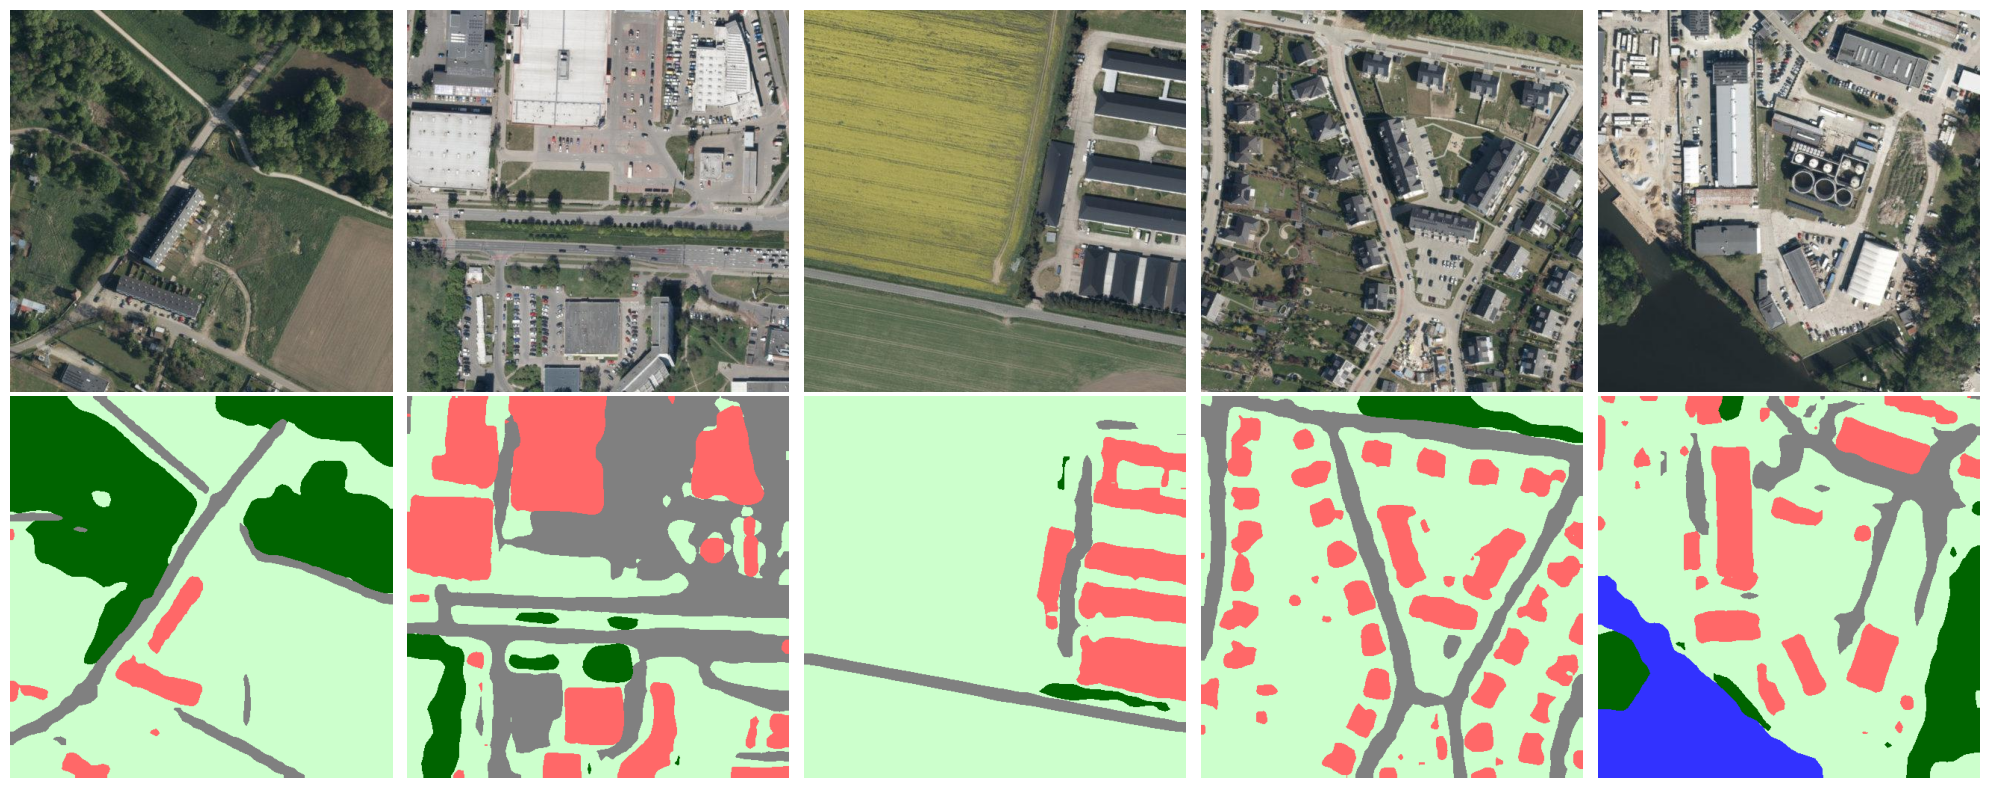

In [62]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

with torch.no_grad():
    for i, filename in enumerate(selected):

        path = os.path.join(DIRECTORY, filename)
        img = Image.open(path).convert("RGB")

        inp = preprocess(img).to(DEVICE)

        logits = model(inp)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
        
        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        colored_mask = decode_mask(pred)
        axes[1, i].imshow(colored_mask)
        axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Wyliczamy pokrycie powierzchni Wrocławia przez poszczególne obszary

In [64]:
DIRECTORY = "tiles_wroclaw_filtered"

files = sorted([
    f for f in os.listdir(DIRECTORY)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

model.eval()

class_counts = np.zeros(len(CLASS_NAMES), dtype=np.float64)
total_pixels = 0

for filename in files:
    path = os.path.join(DIRECTORY, filename)
    img = Image.open(path).convert("RGB")

    inp = preprocess(img).to(DEVICE)

    with torch.no_grad():
        logits = model(inp)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    h, w = pred.shape
    total_pixels += h * w

    for class_id in range(len(CLASS_NAMES)):
        class_counts[class_id] += np.sum(pred == class_id)

print("\n=== LAND COVER OF WROCŁAW ===\n")

for class_id in range(len(CLASS_NAMES)):
    ratio = class_counts[class_id] / total_pixels
    print(f"{CLASS_NAMES[class_id]:>10}: {ratio:.4f} ({ratio*100:.2f}%)")

print("\nTotal pixels processed:", int(total_pixels))


=== LAND COVER OF WROCŁAW ===

background: 0.6204 (62.04%)
 buildings: 0.0737 (7.37%)
    forest: 0.2194 (21.94%)
     water: 0.0203 (2.03%)
     roads: 0.0662 (6.62%)

Total pixels processed: 1493434368
